# Ejercicio 02
## Detección de anomalías en tráfico de red

Trabajo en clase

Msc. William Rodríguez Calvo

Semana 10, Aprendizaje no supervisado

## ¿Para qué sirve este ejercicio?

El objetivo es comparar dos técnicas no supervisadas distintas, Isolation
Forest y DBSCAN, sobre el mismo problema de detección de anomalías, y
entender que el parámetro de contaminación no es un detalle técnico menor
sino una decisión de negocio sobre cuántas falsas alarmas puede tolerar un
equipo de seguridad.

## ¿Qué simula?

El archivo de datos representa 1000 conexiones de red, de las cuales 30 son
ataques. Ninguna de las dos técnicas ve esa etiqueta durante el
entrenamiento, la columna `es_ataque` se revela solo al final, para calificar
qué tan bien logró cada algoritmo separar lo anómalo de lo normal sin haber
visto un solo ejemplo de ataque de antemano.

## ¿Cómo se conecta con la ciberseguridad?

La mayoría de los ataques nuevos no cuentan con ejemplos previos etiquetados,
por lo que un modelo supervisado no tiene con qué entrenarse. Isolation
Forest y DBSCAN representan el enfoque opuesto, aprender qué es normal y
señalar lo que se aleja de ese patrón, la misma lógica que usan muchas
plataformas de detección de anomalías de red en producción.

## Datos

El archivo `datos/trafico_red.csv` contiene las siguientes columnas.

- `conexion_id`, identificador de la conexión.
- `bytes_enviados`, `bytes_recibidos`, volumen de datos transferido.
- `paquetes_por_segundo`, tasa de paquetes de la conexión.
- `conexiones_simultaneas`, conexiones simultáneas asociadas al mismo origen.
- `duracion_conexion_seg`, duración de la conexión en segundos.
- `es_ataque`, la respuesta verdadera. Se usa solo al final para calificar.

## Paso 1
## Cargar y explorar los datos

Objetivo de este paso, cargar los datos y confirmar qué tan desbalanceado
está el problema antes de entrenar nada. `df["es_ataque"].value_counts()`
cuenta cuántas conexiones normales y cuántas de ataque hay en el archivo.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest
from sklearn.cluster import DBSCAN
from sklearn.metrics import classification_report, confusion_matrix

df = pd.read_csv("datos/trafico_red.csv")
print(df.shape)
print(df["es_ataque"].value_counts())
df.head()


(1000, 7)
es_ataque
0    970
1     30
Name: count, dtype: int64


,conexion_id,bytes_enviados,bytes_recibidos,paquetes_por_segundo,conexiones_simultaneas,duracion_conexion_seg,es_ataque
0,1,5255.67,19101.92,6.64,1.00,54.87,0
1,2,2877.72,20632.62,10.72,3.78,31.85,0
2,3,2807.82,13739.25,19.72,2.89,23.69,0
3,4,4321.15,13670.89,13.85,3.77,37.34,0
4,5,3778.78,14484.09,15.43,3.91,68.43,0


**Por qué importa este conteo.** Solo 30 de 1000 conexiones son
ataques, un desbalance de clases fuerte y típico en ciberseguridad, la
mayoría del tráfico siempre es normal. Esto tiene una consecuencia
directa sobre cómo se debe leer cualquier métrica más adelante, un modelo
que marcara todo como normal acertaría el 97 por ciento de las veces y
sin embargo sería inútil, porque no detectaría ni un solo ataque. Por eso
en los pasos siguientes se revisa recall y precisión por separado, no solo
la exactitud general.

## Paso 2
## Preparar y escalar los datos

Objetivo de este paso, dejar las variables en una escala comparable, tanto
Isolation Forest como DBSCAN son sensibles a la magnitud de las variables
usadas.

In [2]:
features = ["bytes_enviados", "bytes_recibidos", "paquetes_por_segundo",
            "conexiones_simultaneas", "duracion_conexion_seg"]

X = df[features].copy()
scaler = StandardScaler()
X_esc = scaler.fit_transform(X)


## Paso 3
## Isolation Forest

Objetivo de este paso, entrenar el primer detector de anomalías y medir
qué tan bien identifica los ataques reales sin haber visto esa etiqueta
durante el entrenamiento. `contamination` es la proporción esperada de
anomalías en los datos. En este ejercicio se conoce de antemano que es
cercana al 3 por ciento, en un caso real este valor se estima con criterio
de negocio o se ajusta por prueba y error.

In [3]:
iso = IsolationForest(n_estimators=200, contamination=0.03, random_state=42)
pred_iso = iso.fit_predict(X_esc)   # -1 anomalía, 1 normal
df["anomalia_iso"] = (pred_iso == -1).astype(int)

print(classification_report(df["es_ataque"], df["anomalia_iso"],
                             target_names=["normal", "ataque"]))
print(confusion_matrix(df["es_ataque"], df["anomalia_iso"]))


              precision    recall  f1-score   support

      normal       1.00      1.00      1.00       970
      ataque       1.00      1.00      1.00        30

    accuracy                           1.00      1000
   macro avg       1.00      1.00      1.00      1000
weighted avg       1.00      1.00      1.00      1000

[[970   0]
 [  0  30]]


¿Cómo leer este resultado? 

El reporte de clasificación muestra, para cada clase, tres valores clave. `precision`, de las conexiones que el modelo marcó como ataque, qué proporción realmente lo eran, un valor bajo significa muchas falsas alarmas. `recall`, de los ataques reales que existían, qué proporción logró detectar el modelo, un valor bajo significa ataques que pasaron desapercibidos. `f1-score`, un balance entre ambas. La matriz de confusión debajo muestra los mismos resultados como una tabla de dos por dos, en el orden normal y ataque tanto en filas (valor real) como en columnas (predicción del modelo), la diagonal principal son los aciertos y las dos celdas fuera de la diagonal son los falsos positivos y los falsos negativos. En un contexto de seguridad, priorizar un recall alto suele ser más importante que priorizar precisión, porque el costo de no detectar un ataque real casi siempre es mayor que el costo de revisar una falsa alarma.

## Paso 4
## DBSCAN como detector de ruido

Objetivo de este paso, entrenar un segundo detector con una lógica distinta, marcar como anómalo lo que DBSCAN clasifica como ruido, y comparar su desempeño contra Isolation Forest sobre el mismo conjunto de datos.

In [4]:
dbscan = DBSCAN(eps=1.2, min_samples=8)
etiquetas_db = dbscan.fit_predict(X_esc)   # -1 significa ruido
df["anomalia_dbscan"] = (etiquetas_db == -1).astype(int)

print(classification_report(df["es_ataque"], df["anomalia_dbscan"],
                             target_names=["normal", "ataque"]))
print(confusion_matrix(df["es_ataque"], df["anomalia_dbscan"]))


              precision    recall  f1-score   support

      normal       1.00      1.00      1.00       970
      ataque       0.91      1.00      0.95        30

    accuracy                           1.00      1000
   macro avg       0.95      1.00      0.98      1000
weighted avg       1.00      1.00      1.00      1000

[[967   3]
 [  0  30]]


Estos números se leen igual que en el paso 3, precisión, recall y
f1-score por clase, más la matriz de confusión. Lo importante en este
punto es comparar ambos resultados lado a lado, no evaluar DBSCAN de forma
aislada, un algoritmo puede tener mejor recall que el otro a costa de más
falsos positivos, esa diferencia es la base para responder las preguntas
de análisis.

## Paso 5
## Comparación visual

Objetivo de este paso, ver en un mismo plano de dos variables cuáles conexiones marcó cada algoritmo como anómalas, para complementar con una imagen las métricas numéricas de los pasos anteriores.

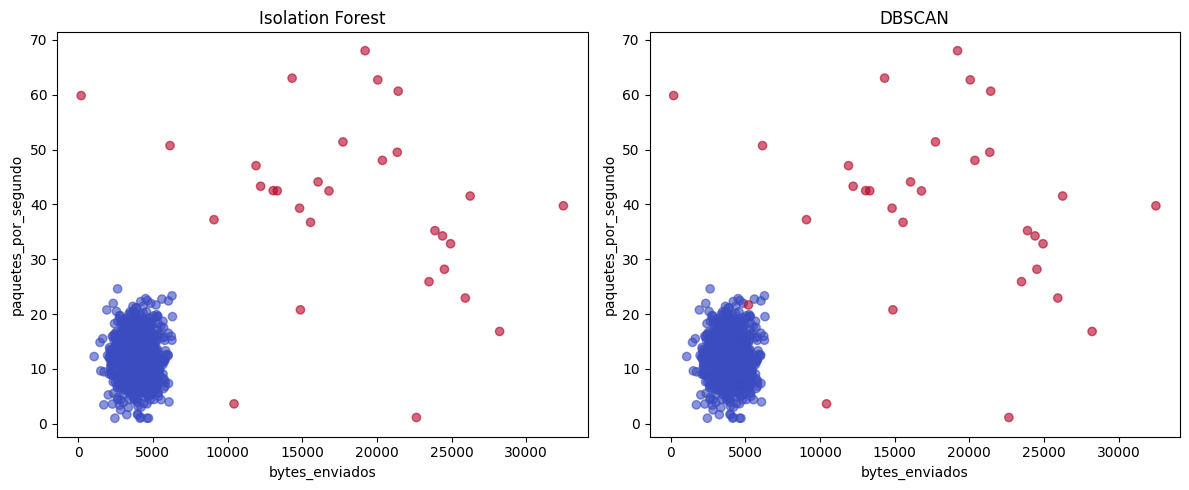

In [5]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

for a, col, titulo in zip(ax, ["anomalia_iso", "anomalia_dbscan"],
                           ["Isolation Forest", "DBSCAN"]):
    a.scatter(df["bytes_enviados"], df["paquetes_por_segundo"],
              c=df[col], cmap="coolwarm", alpha=0.6)
    a.set_xlabel("bytes_enviados")
    a.set_ylabel("paquetes_por_segundo")
    a.set_title(titulo)

plt.tight_layout()
plt.show()


## Preguntas de análisis

1. ¿Cuántas conexiones marcó Isolation Forest como anómalas y cuántas de esas
   eran ataques reales, cuál fue el recall obtenido?
2. Comparen los resultados de DBSCAN contra Isolation Forest, y analizar si los patrones encontrados son similares o muy distintos.
3. ¿Qué pasaría con los resultados si `contamination` se subiera al 10%? Prueben el cambio y describan el efecto sobre los falsos positivos.
4. Para un banco que no quiere saturar a su equipo de seguridad con falsas alarmas, ¿Qué configuración recomendarían y por qué?